<a href="https://colab.research.google.com/github/ompatel420/ML-Practicals/blob/main/ML_P3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **2CEIT506:Machine Learning**
---
# **Practical - 3**
## 24012011117
---
PATEL OMKUMAR VINODCHANDRA
---
5CE-I-1







**AIM: Implementation of Simple Linear Regression using dataset3.xlsx, and Multiple Linear Regression and Polynomial Regression using dataset4.xlsx. Perform data preprocessing, model training, prediction, and evaluation for each regression type. Visualize the results and compare the performance of difierent regression techniques on the given datasets.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt  # seaborn
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [2]:
#import the dataset
dataset = pd.read_excel('/content/drive/MyDrive/ML/Dataset/dataset3-_1_.xlsx-dataset3.xlsx')
dataset

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


1. Simple Linear Regression (dataset3.xlsx)


---


(A) Data Preprocessing



In [3]:
import pandas as pd
dataset = pd.read_excel("/content/drive/MyDrive/ML/Dataset/dataset3-_1_.xlsx-dataset3.xlsx")
# Basic exploration
print(dataset.shape)
dataset.info()
# Preprocessing checks
print("Missing values:\n", dataset.isnull().sum())
print("\nDuplicate rows:", dataset.duplicated().sum())
X = dataset[['YearsExperience']]
Y = dataset['Salary']

(30, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
Missing values:
 YearsExperience    0
Salary             0
dtype: int64

Duplicate rows: 0


(B) Model Training

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, Y_train, Y_test = train_test_split(
X, Y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(X_train, Y_train)


LinearRegression()

(C) Prediction

In [5]:
Y_pred = model.predict(X_test)


(D) Evaluation

In [6]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
slr_mae = mean_absolute_error(Y_test, Y_pred)
slr_mse = mean_squared_error(Y_test, Y_pred)
slr_r2 = r2_score(Y_test, Y_pred)
print("MAE =", slr_mae)
print("MSE =", slr_mse)
print("R2 Score =", slr_r2)

MAE = 2446.1723690465055
MSE = 12823412.298126549
R2 Score = 0.988169515729126


(E) Visualization

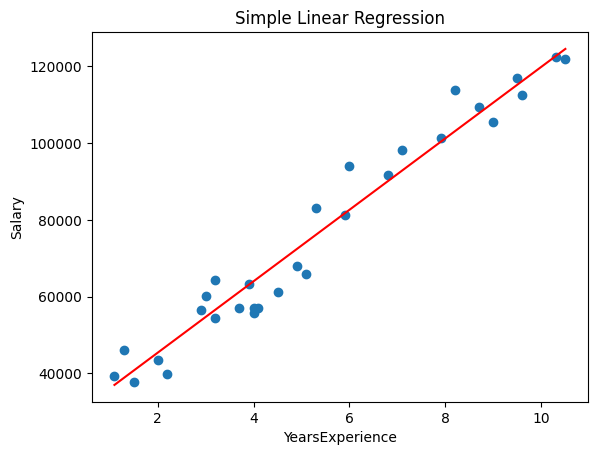

In [7]:
import matplotlib.pyplot as plt
plt.scatter(X, Y)
plt.plot(X, model.predict(X), color='red')
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("Simple Linear Regression")
plt.show()

2. Multiple Linear Regression (dataset4.xlsx)


---
(A) Data Preprocessing



In [8]:
import pandas as pd
dataset = pd.read_excel("/content/drive/MyDrive/ML/Dataset/dataset4 (2).xlsx")
# Basic exploration
print(dataset.shape)
dataset.info()
dataset.describe()
# Preprocessing checks
print("Missing values:\n", dataset.isnull().sum())
print("\nDuplicate rows:", dataset.duplicated().sum())
X = dataset[['R&D Spend',
'Administration',
'Marketing Spend']]
Y = dataset['Profit']

(50, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB
Missing values:
 R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

Duplicate rows: 0


(B) Model Training


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, Y_train, Y_test = train_test_split(
X, Y, test_size=0.2, random_state=0)
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

(C) Prediction

In [10]:
Y_pred = model.predict(X_test)

(D) Evaluation

In [11]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
mlr_mae = mean_absolute_error(Y_test, Y_pred)
mlr_mse = mean_squared_error(Y_test, Y_pred)
mlr_r2 = r2_score(Y_test, Y_pred)
print("MAE =", mlr_mae)
print("MSE =", mlr_mse)
print("R2 Score =", mlr_r2)

MAE = 7320.4416148481305
MSE = 77506468.16885428
R2 Score = 0.9393955917820569


(E) Visualization

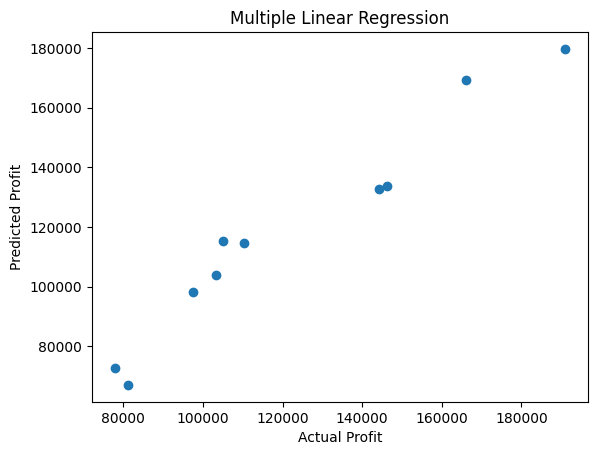

In [12]:
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Multiple Linear Regression")
plt.show()


3. Polynomial Regression (dataset4.xlsx)

---
(A) Data Preprocessing


In [13]:
import pandas as pd
dataset = pd.read_excel("/content/drive/MyDrive/ML/Dataset/dataset4 (2).xlsx")
X = dataset[['R&D Spend']]
Y = dataset['Profit']
# Preprocessing already verified above for this same file — no repeat needed

(B) Model Training — with train/test split (fixed)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
X_train, X_test, Y_train, Y_test = train_test_split(
X, Y, test_size=0.2, random_state=0)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train) # fit + transform on train
X_test_poly = poly.transform(X_test) # transform only on test
model = LinearRegression()
model.fit(X_train_poly, Y_train)


LinearRegression()

(C) Prediction

In [15]:
Y_pred = model.predict(X_test_poly)

(D) Evaluation

In [16]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
poly_mae = mean_absolute_error(Y_test, Y_pred)
poly_mse = mean_squared_error(Y_test, Y_pred)
poly_r2 = r2_score(Y_test, Y_pred)
print("MAE =", poly_mae)
print("MSE =", poly_mse)
print("R2 Score =", poly_r2)

MAE = 7173.521819782587
MSE = 74027530.23341005
R2 Score = 0.9421158676478752


(E) Visualization

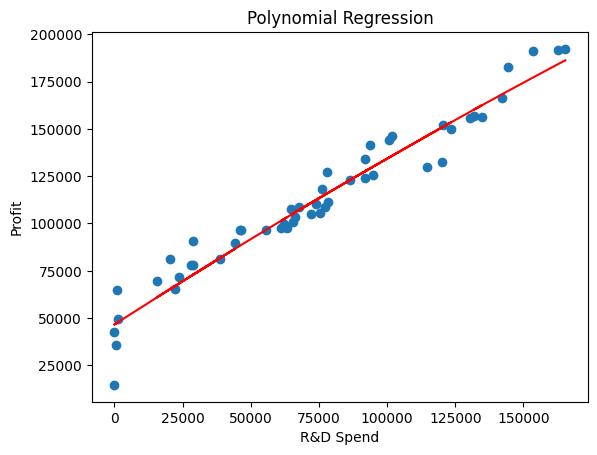

In [17]:
X_poly_full = poly.transform(X) # transform full X for a smooth curve across all points
plt.scatter(X, Y)
plt.plot(X, model.predict(X_poly_full), color='red')
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("Polynomial Regression")
plt.show()

Comparison Table

In [18]:
import pandas as pd
comparison = pd.DataFrame({
'Regression Technique': [
'Simple Linear Regression',
'Multiple Linear Regression',
'Polynomial Regression'
],
'MAE': [slr_mae, mlr_mae, poly_mae],
'MSE': [slr_mse, mlr_mse, poly_mse],
'R2 Score': [slr_r2, mlr_r2, poly_r2]
})
print(comparison)


         Regression Technique          MAE           MSE  R2 Score
0    Simple Linear Regression  2446.172369  1.282341e+07  0.988170
1  Multiple Linear Regression  7320.441615  7.750647e+07  0.939396
2       Polynomial Regression  7173.521820  7.402753e+07  0.942116
